# Machine Learning Based Fraudulent Transaction Detection System

## Objective

The objective of this project is to develop a machine learning-based system capable of detecting fraudulent financial transactions. Multiple supervised learning algorithms are implemented and compared to identify the most effective model. The selected model is then used to predict whether unseen transactions are legitimate or fraudulent.

## 1. Import Libraries

The following Python libraries are used:

- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Imbalanced-learn (SMOTE)
- XGBoost
- Joblib

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [3]:
df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Dataset Understanding

In [4]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

DATASET OVERVIEW
Number of Rows    : 284,807
Number of Columns : 31

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## 4. Data Quality Assessment

### 4.1 Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### 4.2 Statistical Summary

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### 4.3 Missing Value Analysis

In [7]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values
})

missing_df

,Column,Missing Values
0,Time,0
1,V1,0
2,V2,0
3,V3,0
4,V4,0
5,V5,0
6,V6,0
7,V7,0
8,V8,0
9,V9,0


#### Observation

No missing values were identified in the dataset. Therefore, no missing value imputation was required before model development.

### 4.4 Duplicate Record Analysis

In [8]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 1081


#### Observation

The dataset contains duplicate records. These duplicates will be removed during the preprocessing stage to avoid bias during model training.

### 4.5 Data Type Verification

In [9]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

## 5. Exploratory Data Analysis (EDA)

### 5.1 Class Distribution (Fraud vs Genuine)

In [10]:
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


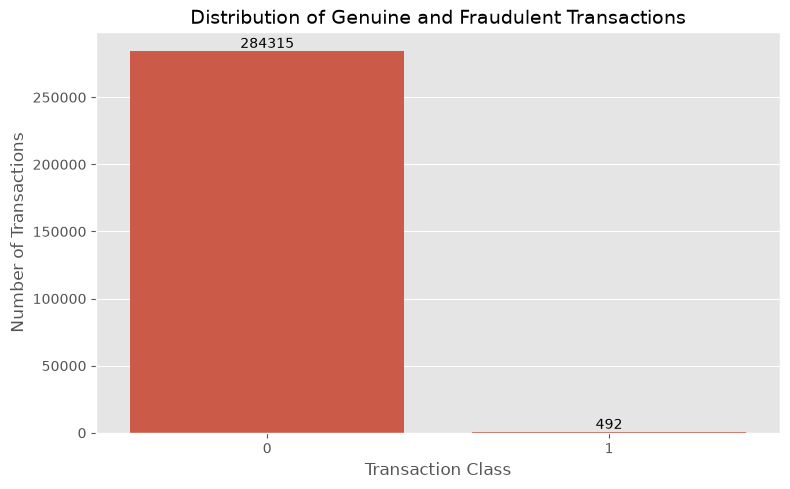

In [11]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x="Class")

plt.title("Distribution of Genuine and Fraudulent Transactions", fontsize=14)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

# Add labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()

plt.savefig("../outputs/figures/class_distribution.png", dpi=300)

plt.show()

The class distribution analysis reveals that the dataset is highly imbalanced. Out of 284,807 transactions, 284,315 (99.83%) are legitimate, while only 492 (0.17%) are fraudulent. Such an imbalance is common in real-world financial datasets and presents a significant challenge for machine learning models. Consequently, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be considered in addition to accuracy.

### 5.2 Percentage Distribution

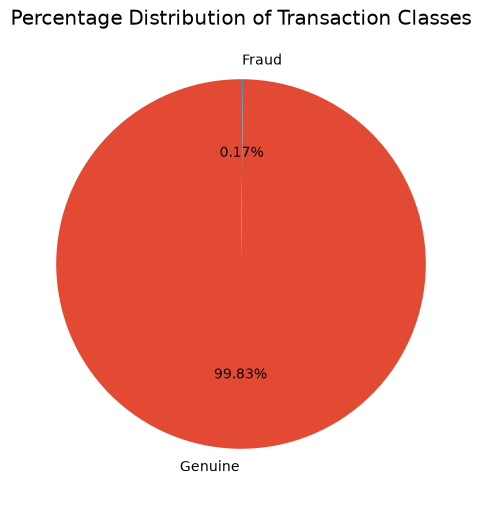

In [12]:
fraud_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(6,6))

plt.pie(
    fraud_percentage,
    labels=["Genuine", "Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Percentage Distribution of Transaction Classes")

plt.savefig("../outputs/figures/class_percentage.png", dpi=300)

plt.show()

#### Observation

The pie chart clearly illustrates the severe class imbalance, with genuine transactions representing nearly the entire dataset. This confirms that special attention is required during model evaluation to ensure that fraudulent transactions are accurately identified despite their limited representation.

### 5.3 Transaction Amount Distribution

This section examines the distribution of transaction amounts to understand their spread and identify potential outliers.

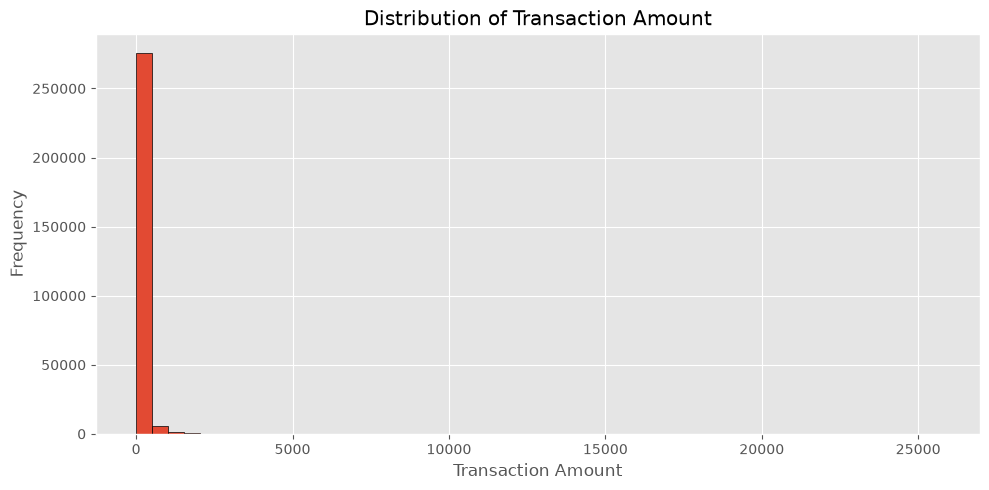

In [13]:
plt.figure(figsize=(10,5))

plt.hist(df["Amount"], bins=50, edgecolor="black")

plt.title("Distribution of Transaction Amount")

plt.xlabel("Transaction Amount")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../outputs/figures/transaction_amount_distribution.png", dpi=300)

plt.show()

In [14]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

### 5.4 Transaction Time Distribution

This section analyses the distribution of transaction time to observe the frequency of transactions recorded throughout the dataset.

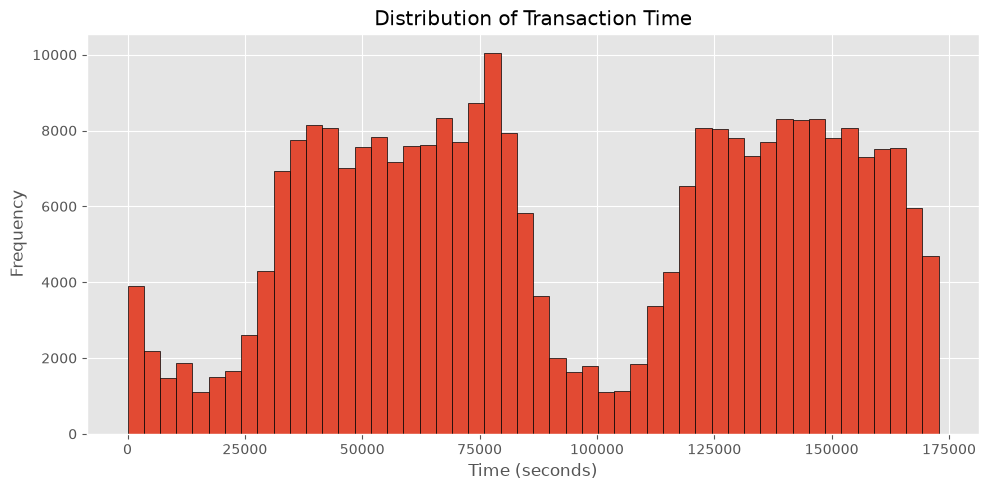

In [15]:
plt.figure(figsize=(10,5))

plt.hist(df["Time"], bins=50, edgecolor="black")

plt.title("Distribution of Transaction Time")

plt.xlabel("Time (seconds)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../outputs/figures/time_distribution.png", dpi=300)

plt.show()

### 5.5 Correlation Analysis

Correlation analysis helps identify relationships between variables in the dataset. A correlation heatmap provides a visual representation of how strongly each feature is related to other features and the target variable. This analysis helps understand the data characteristics before model development.

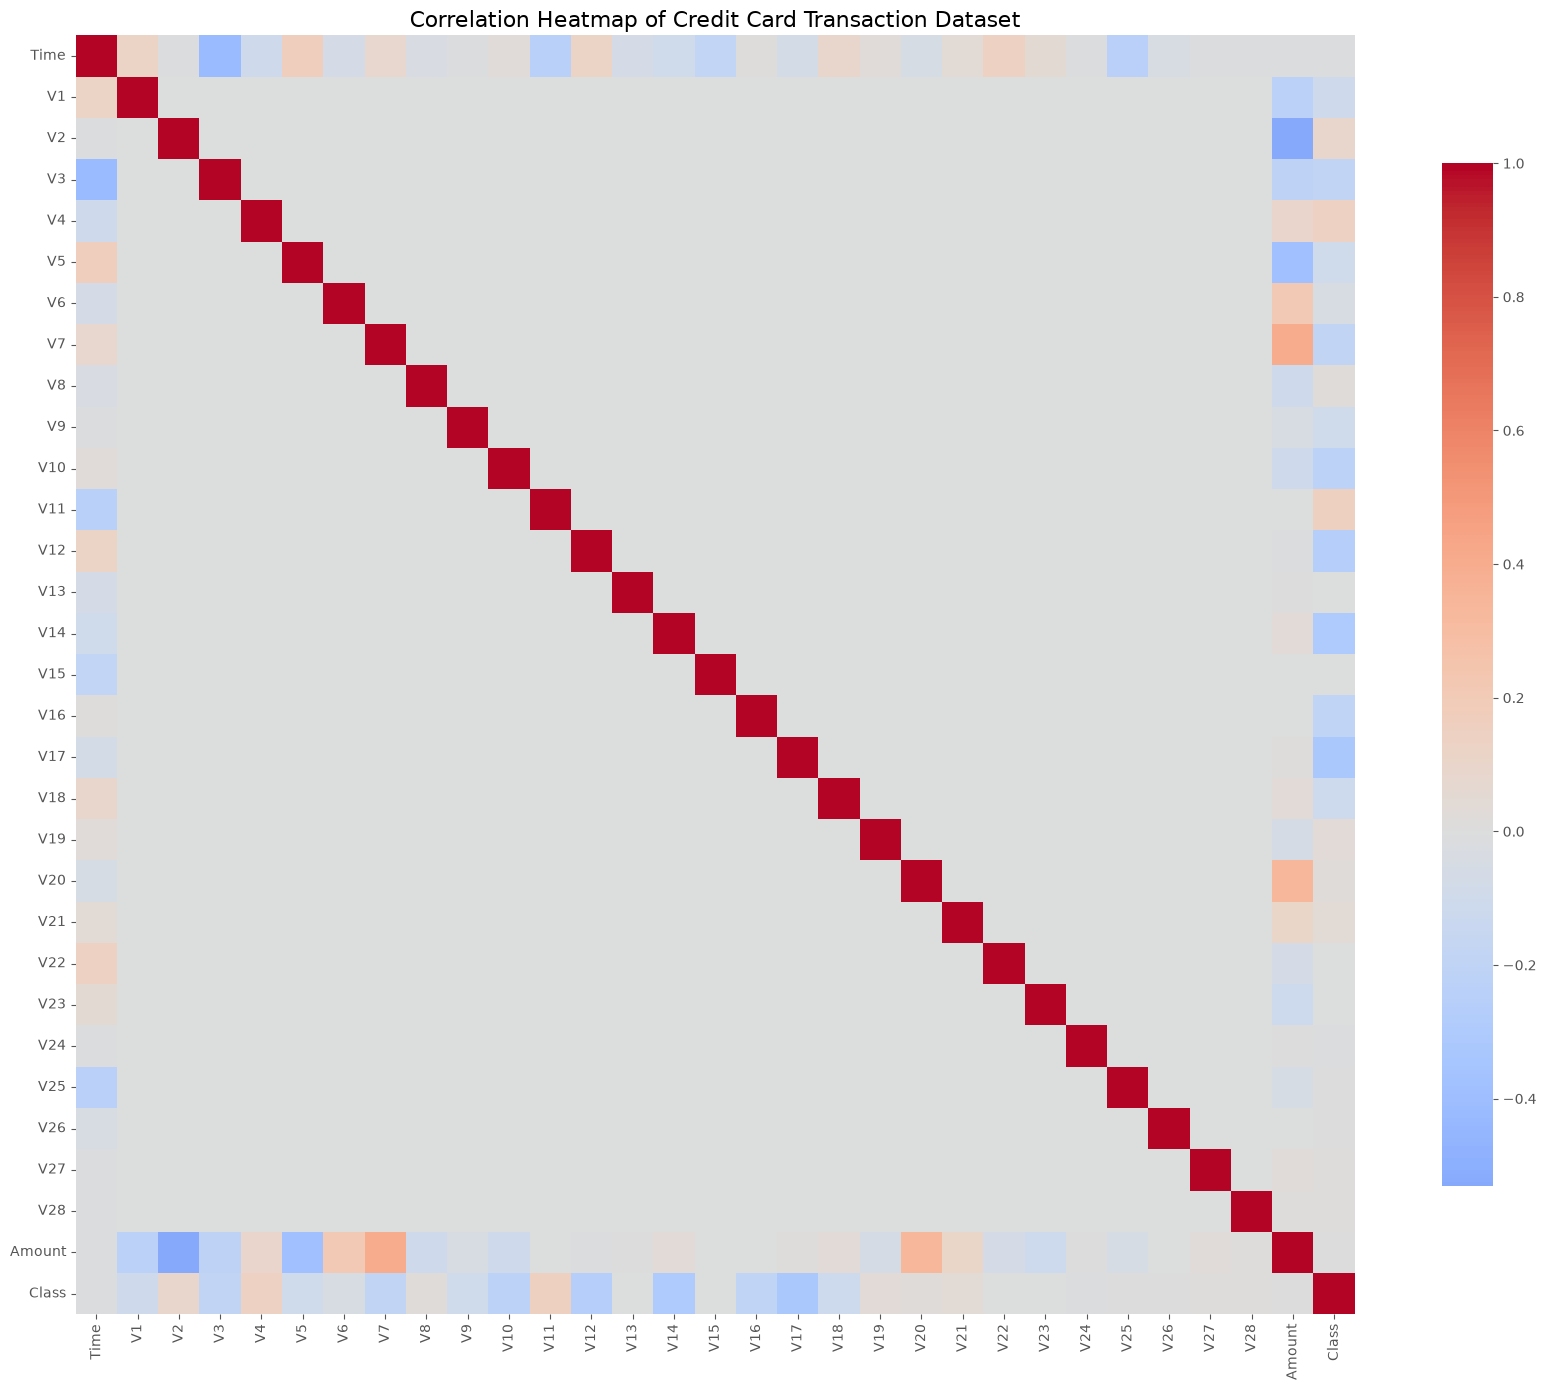

In [16]:
plt.figure(figsize=(18, 14))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Credit Card Transaction Dataset", fontsize=16)

plt.tight_layout()

plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=300)

plt.show()

In [17]:
corr_with_target = (
    df.corr()["Class"]
      .sort_values(ascending=False)
)

corr_with_target

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [18]:
corr_with_target.to_frame(name="Correlation with Class")

,Correlation with Class
Class,1.000000
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536


#### Observation

The correlation analysis indicates that most transformed features (V1–V28) have weak correlations with one another, suggesting limited multicollinearity. However, a few variables exhibit relatively stronger positive or negative correlations with the target variable (`Class`), indicating that they may be useful predictors for distinguishing fraudulent transactions. These relationships will be leveraged by the machine learning models during training.

### 5.6 Transaction Amount by Transaction Class

This section compares the transaction amount distributions for genuine and fraudulent transactions. The analysis helps determine whether fraudulent transactions tend to occur within a particular transaction amount range.

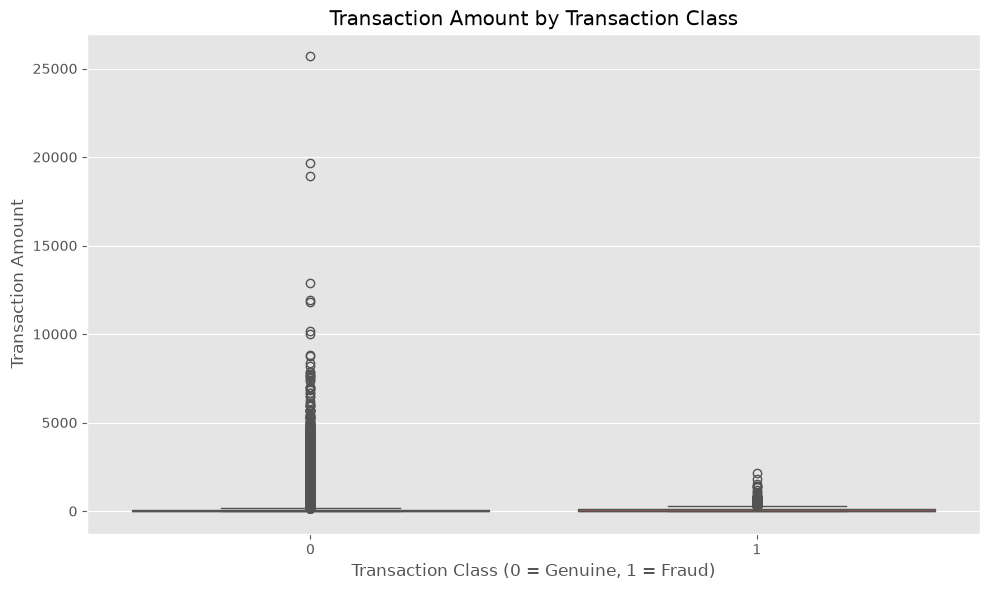

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Transaction Class")

plt.xlabel("Transaction Class (0 = Genuine, 1 = Fraud)")

plt.ylabel("Transaction Amount")

plt.tight_layout()

plt.savefig("../outputs/figures/amount_by_class_boxplot.png", dpi=300)

plt.show()

#### Observation

The box plot compares the transaction amounts for legitimate and fraudulent transactions. Although both classes contain outliers, fraudulent transactions are distributed across different transaction value ranges rather than being limited to only high-value transactions. This indicates that transaction amount alone is insufficient for identifying fraudulent activities, highlighting the importance of considering multiple features during model development.

## 6. Data Preprocessing

Data preprocessing is an essential step in machine learning. It involves preparing the dataset for model training by handling duplicate records, separating features and the target variable, scaling numerical features, splitting the dataset into training and testing sets, and addressing class imbalance. These steps help improve model performance and ensure reliable evaluation.

### 6.1 Duplicate Record Removal

Duplicate records may introduce bias during model training by over-representing certain transactions. Therefore, duplicate records are identified and removed before proceeding with model development.

In [20]:
print("=" * 60)
print("Duplicate Record Analysis")
print("=" * 60)

print(f"Dataset Shape Before Removing Duplicates : {df.shape}")

duplicates = df.duplicated().sum()
print(f"Duplicate Records Found : {duplicates}")

df = df.drop_duplicates()

print(f"Dataset Shape After Removing Duplicates : {df.shape}")

Duplicate Record Analysis
Dataset Shape Before Removing Duplicates : (284807, 31)
Duplicate Records Found : 1081
Dataset Shape After Removing Duplicates : (283726, 31)


#### Observation

A total of **1,081 duplicate records** were identified and removed from the dataset, reducing the number of transactions from **284,807** to **283,726**. Removing duplicate records helps eliminate redundant information and prevents the machine learning models from being biased toward repeated observations.

### 6.2 Feature and Target Separation

The dataset is divided into input features (X) and the target variable (y). The 'Class' column is used as the target variable, where 0 represents a legitimate transaction and 1 represents a fraudulent transaction.

In [21]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (283726, 30)
Target Vector Shape  : (283726,)


#### Observation

The dataset was successfully separated into input features and the target variable. The feature matrix consists of **30 predictor variables**, while the target variable contains the transaction class labels, where **0** represents genuine transactions and **1** represents fraudulent transactions.

### 6.3 Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The `stratify` parameter is applied to preserve the original class distribution in both sets.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (226980, 30)
Testing Set  : (56746, 30)


#### Observation

The dataset was divided into **80% training data** and **20% testing data** using stratified sampling. This ensures that both datasets preserve the original class distribution, resulting in **226,980 training records** and **56,746 testing records**.

### 6.4 Feature Scaling

Feature scaling standardizes numerical features to a common scale, ensuring that variables with larger values do not disproportionately influence the machine learning models. StandardScaler is used to transform the training and testing datasets.

In [23]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("Training Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)

Feature scaling completed successfully!
Training Shape : (226980, 30)
Testing Shape  : (56746, 30)


#### Observation

StandardScaler was applied to normalize the feature values. The scaler was fitted using only the training dataset and then applied to the testing dataset to prevent data leakage. This preprocessing step is particularly important for algorithms such as Logistic Regression.

### 6.5 Handling Class Imbalance using SMOTE

The training dataset exhibits a significant class imbalance, with fraudulent transactions representing only a small fraction of the observations. To improve the model's ability to learn minority class patterns, the Synthetic Minority Over-sampling Technique (SMOTE) is applied exclusively to the training dataset.

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


#### Observation

Before applying SMOTE, the training dataset contained **226,602 legitimate transactions** and only **378 fraudulent transactions**, indicating a severe class imbalance. After applying SMOTE, both classes contained **226,602 records**, resulting in a balanced training dataset. The testing dataset was intentionally left unchanged to ensure unbiased model evaluation on real-world data.

## 7. Model Building

This section develops multiple supervised machine learning models for fraudulent transaction detection. Each model is trained using the balanced training dataset and evaluated using the same performance metrics to ensure a fair comparison.

### 7.1 Model Evaluation Function

A reusable evaluation function is created to ensure that all machine learning models are assessed using identical evaluation criteria. This improves consistency and simplifies model comparison.

In [25]:
# Store model performance
results = []

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

def evaluate_model(model, model_name):
    
    # Train
    model.fit(X_train_smote, y_train_smote)
    
    # Prediction
    y_pred = model.predict(X_test_scaled)
    
    # Probability (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = y_pred
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Save results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })
    
    print("="*60)
    print(model_name)
    print("="*60)
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    
    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )
    
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

### 7.2 Logistic Regression

Logistic Regression is used as the baseline classification model for fraudulent transaction detection. The model is trained using the balanced training dataset and evaluated on the original testing dataset.

Logistic Regression
Accuracy : 0.9737
Precision: 0.0530
Recall   : 0.8737
F1 Score : 0.1000
ROC-AUC  : 0.9626

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



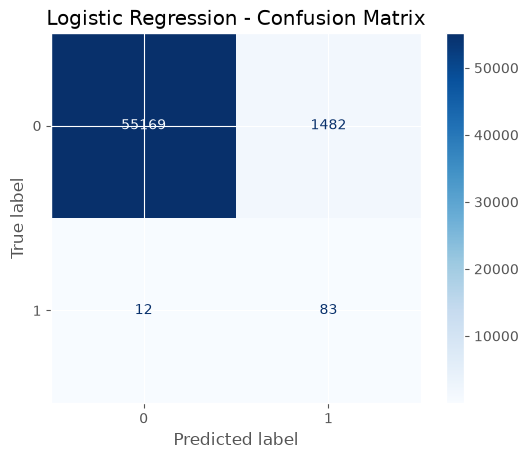

In [26]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

evaluate_model(
    logistic_model,
    "Logistic Regression"
)

#### Observation

The Logistic Regression model was successfully trained and evaluated. Despite its simplicity, it provides a strong baseline for comparison with more advanced machine learning algorithms.

### 7.3 Decision Tree

A Decision Tree classifier is trained to identify fraudulent transactions by learning decision rules from the training data.

Decision Tree
Accuracy : 0.9974
Precision: 0.3526
Recall   : 0.6421
F1 Score : 0.4552
ROC-AUC  : 0.8201

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.35      0.64      0.46        95

    accuracy                           1.00     56746
   macro avg       0.68      0.82      0.73     56746
weighted avg       1.00      1.00      1.00     56746



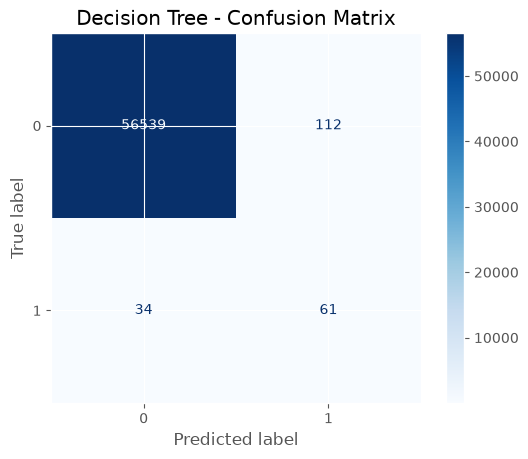

In [27]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(
    decision_tree,
    "Decision Tree"
)

### 7.4 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Random Forest
Accuracy : 0.9995
Precision: 0.9125
Recall   : 0.7684
F1 Score : 0.8343
ROC-AUC  : 0.9694

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



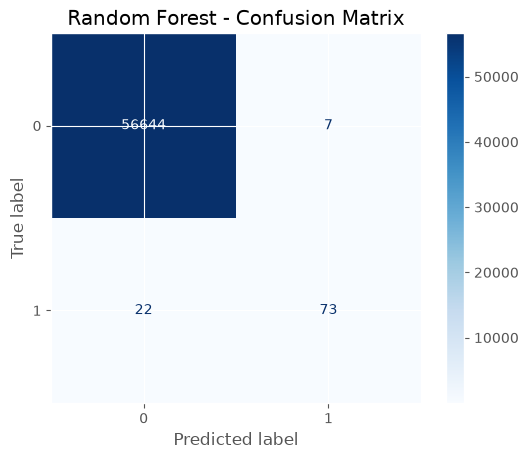

In [28]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

evaluate_model(
    random_forest,
    "Random Forest"
)

### 7.5 XGBoost

XGBoost is an advanced gradient boosting algorithm widely used for classification tasks due to its high predictive performance and efficiency.

XGBoost
Accuracy : 0.9992
Precision: 0.7426
Recall   : 0.7895
F1 Score : 0.7653
ROC-AUC  : 0.9702

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.74      0.79      0.77        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



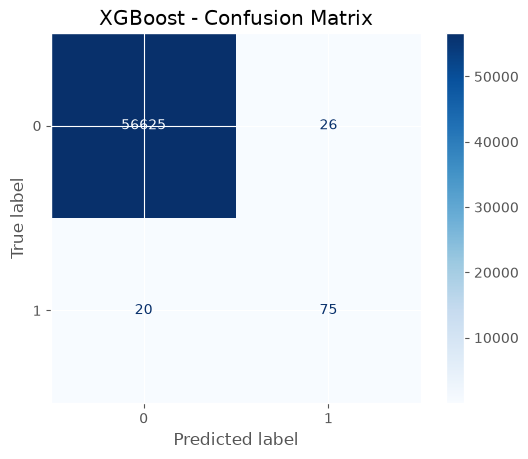

In [29]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

evaluate_model(
    xgboost_model,
    "XGBoost"
)

## 8. Model Comparison

The performance of all machine learning models is compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. These metrics provide a comprehensive evaluation of each model's ability to detect fraudulent transactions.

In [30]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000,0.962618
1,Decision Tree,0.997427,0.352601,0.642105,0.455224,0.820064
2,Random Forest,0.999489,0.912500,0.768421,0.834286,0.969390
3,XGBoost,0.999189,0.742574,0.789474,0.765306,0.970154


#### Round the Values

In [31]:
results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9737,0.0530,0.8737,0.1000,0.9626
1,Decision Tree,0.9974,0.3526,0.6421,0.4552,0.8201
2,Random Forest,0.9995,0.9125,0.7684,0.8343,0.9694
3,XGBoost,0.9992,0.7426,0.7895,0.7653,0.9702


#### Save Results

In [32]:
results_df.to_csv("../outputs/model_comparison.csv", index=False)

#### Performance Comparison Graph

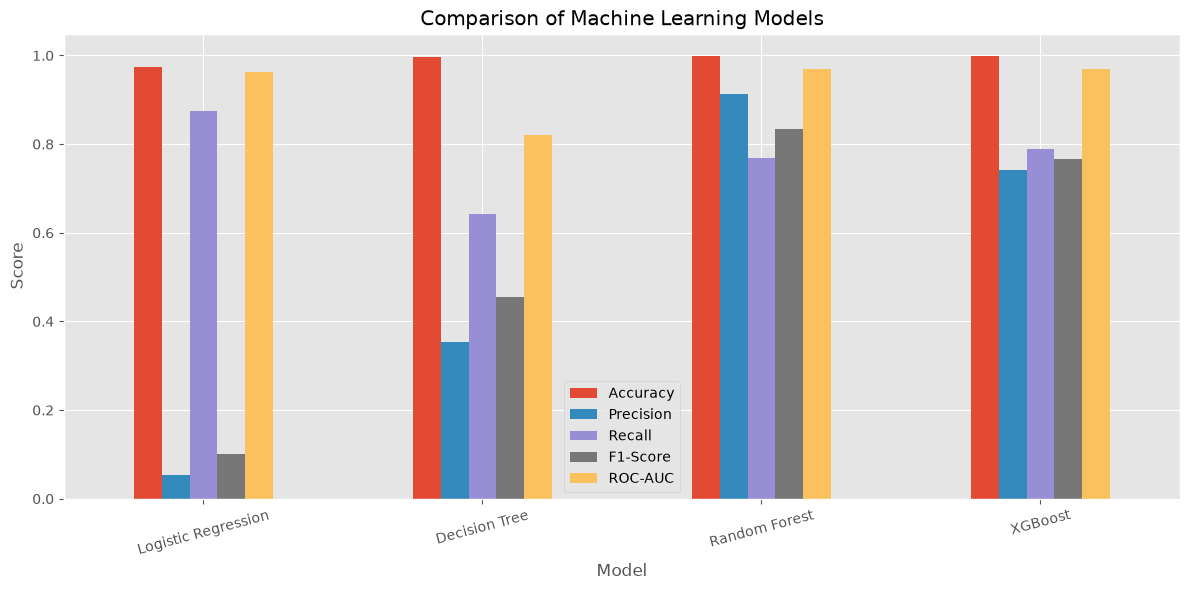

In [33]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("../outputs/figures/model_comparison.png", dpi=300)

plt.show()

#### Observation

Among the four machine learning algorithms evaluated, Random Forest achieved the highest overall performance with excellent Accuracy (99.95%), Precision (91.25%), and F1-Score (83.43%). XGBoost also demonstrated strong performance, particularly in terms of Recall and ROC-AUC. Logistic Regression achieved the highest Recall but generated a large number of false positives, resulting in very low Precision. Based on the overall evaluation metrics, Random Forest was selected as the best-performing model for fraudulent transaction detection.

## 9. Fraud Detection System

After comparing all machine learning algorithms, the Random Forest model was selected as the final model. The trained model and feature scaler are saved so that they can be reused to classify new transactions without retraining.

### 9.1 Save the Best Model

In [34]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(random_forest, "../models/random_forest_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Random Forest model saved successfully!")
print("Scaler saved successfully!")

Random Forest model saved successfully!
Scaler saved successfully!


### 9.2 Loading the Trained Model

The saved Random Forest model and feature scaler are loaded for predicting unseen transactions.

In [35]:
loaded_model = joblib.load("../models/random_forest_model.pkl")

loaded_scaler = joblib.load("../models/scaler.pkl")

print("Model loaded successfully.")

Model loaded successfully.


### 9.3 Fraud Prediction on Unseen Transactions

The trained Random Forest model is used to predict unseen transactions from the testing dataset. A random sample of transactions is selected to demonstrate the model's fraud detection capability. The predicted results are then compared with the actual class labels.

In [43]:
# sample_transactions = X_test.iloc[:10]

# sample_transactions_scaled = loaded_scaler.transform(sample_transactions)

# predictions = loaded_model.predict(sample_transactions_scaled)

# probabilities = loaded_model.predict_proba(sample_transactions_scaled)

import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Randomly select 10 transactions from the test set
random_indices = np.random.choice(
    X_test.index,
    size=10,
    replace=False
)

sample_transactions = X_test.loc[random_indices]

actual_labels = y_test.loc[random_indices]

#### 9.4 Scale and predict

In [44]:
sample_transactions_scaled = loaded_scaler.transform(sample_transactions)

predictions = loaded_model.predict(sample_transactions_scaled)

probabilities = loaded_model.predict_proba(sample_transactions_scaled)

### 9.5 Display Results

In [45]:
prediction_results = sample_transactions.copy()

# prediction_results["Actual Class"] = y_test.iloc[:10].values
prediction_results["Actual Class"] = actual_labels.values

prediction_results["Predicted Class"] = predictions

# prediction_results["Fraud Probability"] = probabilities[:, 1]
prediction_results["Fraud Probability"] = np.round(
    probabilities[:,1],
    4
)

prediction_results["Prediction Result"] = prediction_results[
    "Predicted Class"
].map({
    0: "Legitimate",
    1: "Fraudulent"
})

prediction_results[
    [
        "Actual Class",
        "Predicted Class",
        "Fraud Probability",
        "Prediction Result"
    ]
]

,Actual Class,Predicted Class,Fraud Probability,Prediction Result
31580,0,0,0.00,Legitimate
65974,0,0,0.00,Legitimate
268368,0,0,0.02,Legitimate
144177,0,0,0.00,Legitimate
6323,0,0,0.01,Legitimate
279097,0,0,0.00,Legitimate
164997,0,0,0.00,Legitimate
97193,0,0,0.00,Legitimate
132753,0,0,0.00,Legitimate
6270,0,0,0.00,Legitimate


### 9.6 Save Prediction Results

In [46]:
prediction_results.to_csv(
    "../outputs/sample_predictions.csv",
    index=False
)

print("Prediction results saved successfully!")

Prediction results saved successfully!


### 9.7 Prediction Summary

In [48]:
print("="*60)

print("Prediction Summary")

print("="*60)

print(prediction_results["Prediction Result"].value_counts())

Prediction Summary
Prediction Result
Legitimate    10
Name: count, dtype: int64


### 9.8 Function to Predict a fraud Transaction

In [49]:
def predict_transaction(transaction):

    transaction_scaled = loaded_scaler.transform(transaction)

    prediction = loaded_model.predict(transaction_scaled)[0]

    fraud_probability = loaded_model.predict_proba(transaction_scaled)[0][1]

    result = "Fraudulent" if prediction == 1 else "Legitimate"

    print("=" * 60)
    print("Fraud Detection Result")
    print("=" * 60)
    print(f"Prediction        : {result}")
    print(f"Fraud Probability : {fraud_probability:.2%}")

    return prediction, fraud_probability

### 9.9 Finding fraud transaction from the test set

In [52]:
# Find fraud transactions in the test set
fraud_indices = y_test[y_test == 1].index

if len(fraud_indices) > 0:
    demo_index = fraud_indices[0]
else:
    demo_index = X_test.index[0]

print(f"Transaction Index : {demo_index}")

#predict
prediction, probability = predict_transaction(
    X_test.loc[[demo_index]]
)

# Get actual class
actual = y_test.loc[demo_index]

actual_text = "Fraudulent" if actual == 1 else "Legitimate"

print(f"\nActual Class      : {actual_text}")

# Check whether prediction is correct
if prediction == actual:
    print("Prediction Status : Correct ✅")
else:
    print("Prediction Status : Incorrect ❌")

Transaction Index : 116139
Fraud Detection Result
Prediction        : Fraudulent
Fraud Probability : 99.00%

Actual Class      : Fraudulent
Prediction Status : Correct ✅


## 10. Conclusion

This project successfully developed a Machine Learning-Based Fraudulent Transaction Detection System using supervised learning algorithms. The dataset was preprocessed through duplicate removal, feature scaling, train-test splitting, and SMOTE to address class imbalance. Four classification algorithms—Logistic Regression, Decision Tree, Random Forest, and XGBoost—were implemented and evaluated. Among these, Random Forest demonstrated the best overall performance and was selected as the final model. The results indicate that machine learning techniques can effectively assist financial institutions in detecting fraudulent transactions and reducing financial losses.